In [53]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
import pandas as pd

# mpl.rcParams['figure.figsize'] = (10, 8)
# mpl.rcParams['axes.grid'] = False


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
df = pd.read_csv("/content/drive/MyDrive/TimeSeriesForecasting/electricity_consumption.csv")
df.head()

,Bill_Date,On_peak,Off_peak,Usage_charge,Billed_amount,Billing_days
0,1/1/2016,365,1423.5,219.0,247.73,31
1,2/1/2016,292,1138.8,175.2,234.11,31
2,3/1/2016,130,507.0,78.0,123.85,29
3,4/1/2016,117,456.3,70.2,111.22,29
4,5/1/2016,136,530.4,81.6,118.37,29


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Bill_Date      53 non-null     object 
 1   On_peak        53 non-null     int64  
 2   Off_peak       53 non-null     float64
 3   Usage_charge   53 non-null     float64
 4   Billed_amount  53 non-null     float64
 5   Billing_days   53 non-null     int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 2.6+ KB


In [57]:
df['Bill_Date'] = pd.to_datetime(df['Bill_Date'], format='%m/%d/%Y')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Bill_Date      53 non-null     datetime64[ns]
 1   On_peak        53 non-null     int64         
 2   Off_peak       53 non-null     float64       
 3   Usage_charge   53 non-null     float64       
 4   Billed_amount  53 non-null     float64       
 5   Billing_days   53 non-null     int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 2.6 KB


In [59]:
df.isnull().sum()

,0
Bill_Date,0
On_peak,0
Off_peak,0
Usage_charge,0
Billed_amount,0
Billing_days,0


In [60]:
bill_df=df.set_index("Bill_Date")

In [61]:
bill_df.head()

,On_peak,Off_peak,Usage_charge,Billed_amount,Billing_days
Bill_Date,,,,,
2016-01-01,365,1423.5,219.0,247.73,31
2016-02-01,292,1138.8,175.2,234.11,31
2016-03-01,130,507.0,78.0,123.85,29
2016-04-01,117,456.3,70.2,111.22,29
2016-05-01,136,530.4,81.6,118.37,29


In [62]:
import matplotlib.dates as mdates

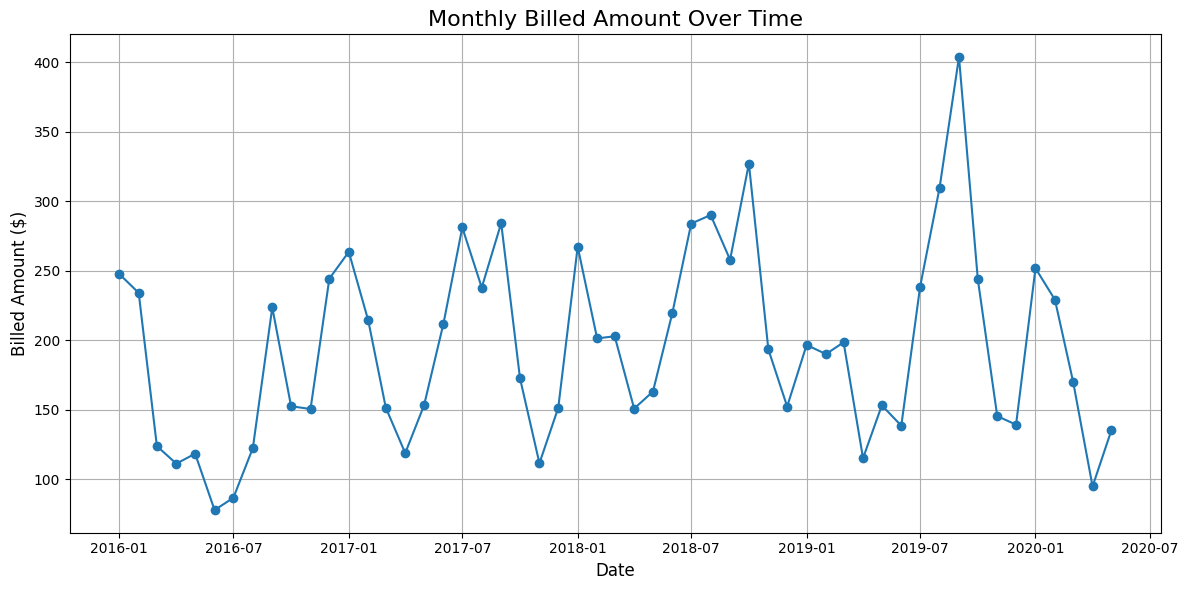

In [63]:

plt.figure(figsize=(12, 6))
plt.plot(bill_df.index, bill_df['Billed_amount'], marker='o', linestyle='-')
plt.title('Monthly Billed Amount Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Billed Amount ($)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [64]:
import plotly.express as px

In [65]:
# Create the interactive line plot with Plotly Express
bill_df_reset = bill_df.reset_index()
fig = px.line(
    bill_df_reset,
    x='Bill_Date',
    y='Billed_amount',
    title='Interactive Monthly Billed Amount Over Time'
)

# Customize the plot layout
fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Billed Amount ($)',
    font=dict(
        family="Courier New, monospace",
        size=12,
        color="#7f7f7f"
    )
)

# Display the interactive plot
fig.show()


In [66]:
bill_df.describe()

,On_peak,Off_peak,Usage_charge,Billed_amount,Billing_days
count,53.000000,53.000000,53.000000,53.000000,53.000000
mean,232.811321,1089.292453,175.957170,194.535094,30.207547
std,106.888162,411.011878,67.797382,68.951708,1.974438
min,63.000000,245.700000,37.800000,77.810000,25.000000
25%,147.000000,777.000000,128.120000,145.460000,29.000000
50%,211.000000,1103.000000,181.850000,193.490000,31.000000
75%,316.000000,1353.300000,218.870000,244.030000,31.000000
max,501.000000,2139.000000,371.610000,403.890000,34.000000


In [67]:
bill_2018 = bill_df['2016':'2018'][["Billed_amount"]]

In [68]:
bill_2018

,Billed_amount
Bill_Date,
2016-01-01,247.73
2016-02-01,234.11
2016-03-01,123.85
2016-04-01,111.22
2016-05-01,118.37
2016-06-01,77.81
2016-07-01,86.67
2016-08-01,122.40
2016-09-01,223.62


#Simple Moving average

Simple moving average = (t + (t-1) + (t-2) + ... + (t-n)) / n

In [69]:
bill_2018['Billed_amount'].rolling(window=3).mean()

,Billed_amount
Bill_Date,
2016-01-01,NaN
2016-02-01,NaN
2016-03-01,201.896667
2016-04-01,156.393333
2016-05-01,117.813333
2016-06-01,102.466667
2016-07-01,94.283333
2016-08-01,95.626667
2016-09-01,144.230000


In [70]:
bill_2018['ma_rolling_3']=bill_2018['Billed_amount'].rolling(window=3).mean().shift(1)

In [71]:
bill_2018

,Billed_amount,ma_rolling_3
Bill_Date,,
2016-01-01,247.73,NaN
2016-02-01,234.11,NaN
2016-03-01,123.85,NaN
2016-04-01,111.22,201.896667
2016-05-01,118.37,156.393333
2016-06-01,77.81,117.813333
2016-07-01,86.67,102.466667
2016-08-01,122.40,94.283333
2016-09-01,223.62,95.626667


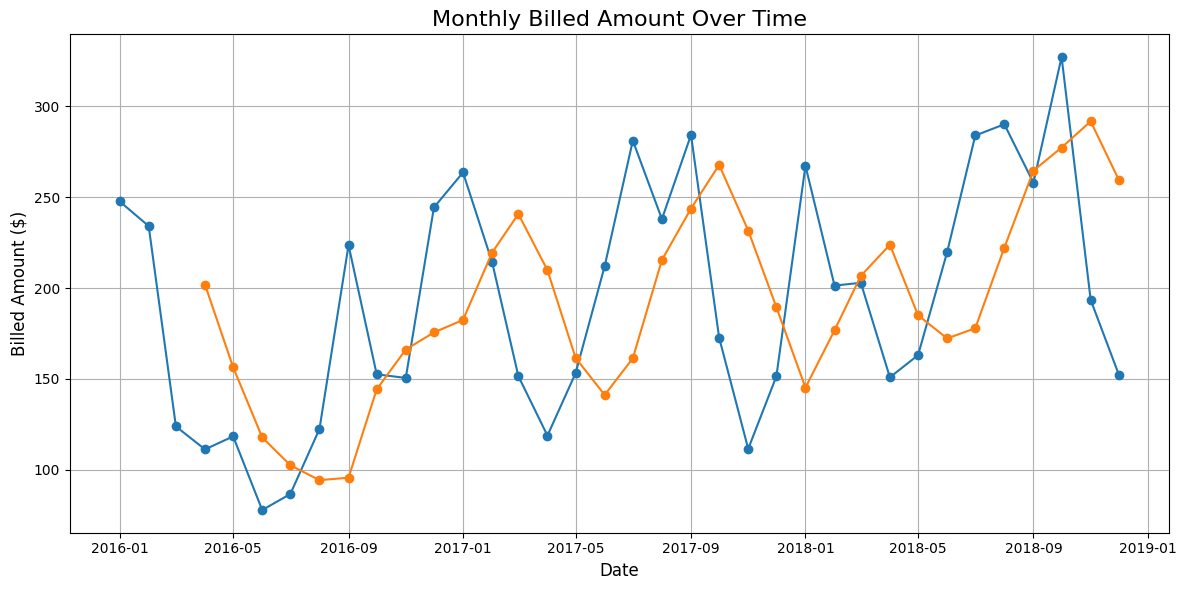

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(bill_2018.index, bill_2018['Billed_amount'], marker='o', linestyle='-')
plt.plot(bill_2018.index, bill_2018['ma_rolling_3'], marker='o', linestyle='-')
plt.title('Monthly Billed Amount Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Billed Amount ($)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Weighted moving average = (t * weighting factor) + ((t-1) * weighting factor-1) + ((t-n) * weighting factor-n)/n

In [73]:
weights = np.array([0.2, 0.3, 0.5])

In [74]:
# Calculate the weighted moving average using a rolling window with the apply method
bill_2018['wma_rolling_3']=bill_2018['Billed_amount'].rolling(window=3).apply(lambda x: (x * weights).sum(), raw=True).shift(1)

In [75]:
bill_2018

,Billed_amount,ma_rolling_3,wma_rolling_3
Bill_Date,,,
2016-01-01,247.73,NaN,NaN
2016-02-01,234.11,NaN,NaN
2016-03-01,123.85,NaN,NaN
2016-04-01,111.22,201.896667,181.704
2016-05-01,118.37,156.393333,139.587
2016-06-01,77.81,117.813333,117.321
2016-07-01,86.67,102.466667,96.660
2016-08-01,122.40,94.283333,90.352
2016-09-01,223.62,95.626667,102.763


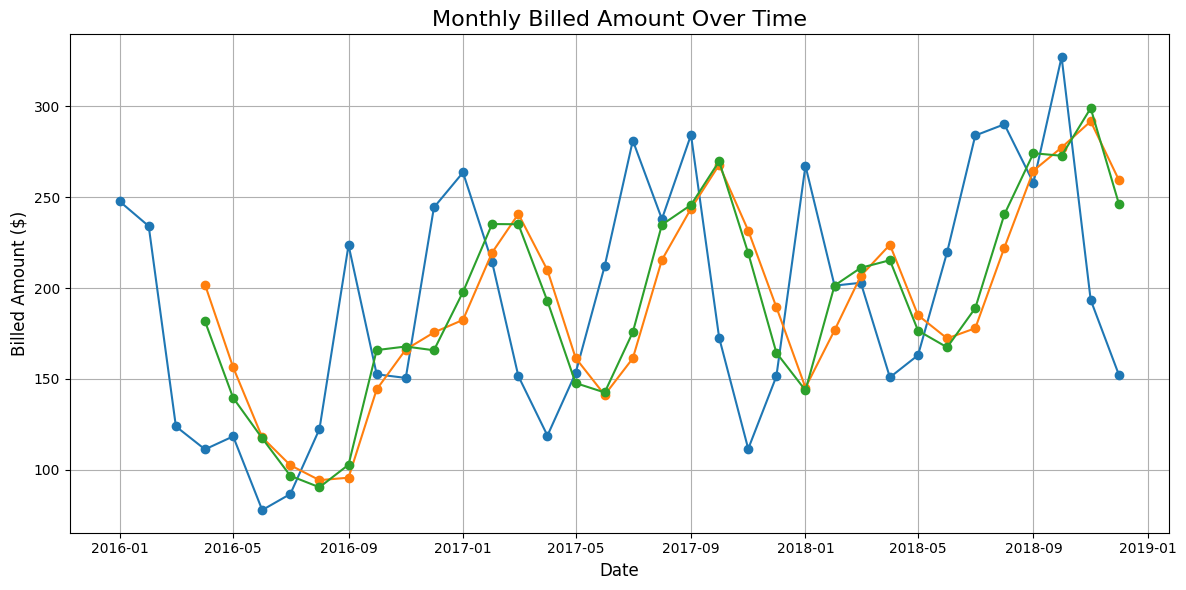

In [77]:
plt.figure(figsize=(12, 6))
plt.plot(bill_2018.index, bill_2018['Billed_amount'], marker='o', linestyle='-')
plt.plot(bill_2018.index, bill_2018['ma_rolling_3'], marker='o', linestyle='-')
plt.plot(bill_2018.index, bill_2018['wma_rolling_3'], marker='o', linestyle='-')
plt.title('Monthly Billed Amount Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Billed Amount ($)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

#Metrics

Mean Absolute Error

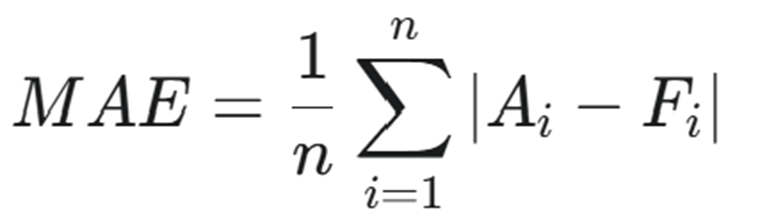

In [ ]:
from sklearn.metrics import mean_absolute_error

In [81]:
# bill_2018.dropna(inplace=True)
MAE_MA= mean_absolute_error(bill_2018['Billed_amount'],bill_2018['ma_rolling_3'])

In [82]:
MAE_MA

58.921515151515145

In [83]:
MAE_wMA= mean_absolute_error(bill_2018['Billed_amount'],bill_2018['wma_rolling_3'])

In [84]:
MAE_wMA

53.47666666666667

In [85]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv")


In [86]:
df

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14.0
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7
